# 第12章 豆瓣网络数据分析

## 12.1 数据处理

（1）重新将已经保存好的数据读取到内存里进行数据处理

In [43]:
with open(r'.\db_data.txt', 'r', encoding='utf-8') as f1:
    data = f1.read()
    print(type(data))
    print(data[:159])

    new_data = eval(data)  # 把字符串内容重新解释成代码
    print(new_data[:2])

<class 'str'>
[{'title': '解忧杂货店', 'price': ' 39.50元', 'star': 8.5}, {'title': '活着', 'price': ' 20.00元', 'star': 9.3}, {'title': '追风筝的人', 'price': ' 29.00元', 'star': 8.9}, {'
[{'title': '解忧杂货店', 'price': ' 39.50元', 'star': 8.5}, {'title': '活着', 'price': ' 20.00元', 'star': 9.3}]


（2）将f3中的每一个元素中的值提取出俩组成列表k，列表k中的每一个元素都是一个由 [小说名称, 价格, 评分] 组成的列表

In [44]:
with open(r'.\db_data.txt', 'r', encoding='utf-8') as f1:
    data = f1.read()
    new_data = eval(data)  # 把字符串内容重新解释成代码
    
k = []
for i in new_data:
    k.append(list(i.values()))
k[:10]

[['解忧杂货店', ' 39.50元', 8.5],
 ['活着', ' 20.00元', 9.3],
 ['追风筝的人', ' 29.00元', 8.9],
 ['三体', ' 23.00', 8.8],
 ['白夜行', ' 29.80元', 9.1],
 ['小王子', ' 22.00元', 9.0],
 ['房思琪的初恋乐园', ' 45.00元', 9.2],
 ['嫌疑人X的献身', ' 28.00', 8.9],
 ['失踪的孩子', ' 62.00元', 9.2],
 ['围城', ' 19.00', 8.9]]

（3）将列表k处理成数据框df，便于后面的数据清洗

In [45]:
import pandas as pd

df = pd.DataFrame(columns=["title", "price", "score"])
p = 0
for j in k:
    df.loc[p] = j
    p += 1
df.tail()

,title,price,score
1479,大唐明月1·风起长安,27.00元,8.6
1480,伊斯坦布尔,36.00元,8.4
1481,如果蜗牛有爱情,45.00,7.0
1482,人性的因素,62.00元,8.7
1483,翅鬼,45,7.3


## 12.2 计算平均分

In [46]:
df

,title,price,score
0,解忧杂货店,39.50元,8.5
1,活着,20.00元,9.3
2,追风筝的人,29.00元,8.9
3,三体,23.00,8.8
4,白夜行,29.80元,9.1
...,...,...,...
1479,大唐明月1·风起长安,27.00元,8.6
1480,伊斯坦布尔,36.00元,8.4
1481,如果蜗牛有爱情,45.00,7.0
1482,人性的因素,62.00元,8.7


In [47]:
print(df.columns.tolist())
print(df.head())

['title', 'price', 'score']
   title    price score
0  解忧杂货店   39.50元   8.5
1     活着   20.00元   9.3
2  追风筝的人   29.00元   8.9
3     三体    23.00   8.8
4    白夜行   29.80元   9.1


In [48]:
# 数据清洗：转换score列为数值类型
df['score'] = pd.to_numeric(df['score'], errors='coerce')
df['score'] = df['score'].fillna(0)

# 计算平均分
df['score'].mean()

np.float64(8.327021563342317)

In [49]:
df['score'] = pd.to_numeric(df['score'], errors='coerce')

In [50]:
df['score'].isnull().any()

np.False_

In [51]:
df['score'][df['score'].isnull().values==True]

Series([], Name: score, dtype: float64)

In [52]:
df['score'] = df['score'].fillna(0)
df['score'].isnull().any()

np.False_

In [53]:
df['score'].mean()

np.float64(8.327021563342317)

## 12.3 计算均价

In [54]:
for p in df["price"]:
    try:
        float(str(p).replace("元", "").strip())
    except:
        print(p)

 CNY 39.50
 CNY 35.00
 大塊文化
 160 TWD
 CNY 79.60
 CNY 79.80
 132.00（全三册）
 臺幣1200圓
 NT330元
 CNY 32.00
 168.00（全三册）
 CNY 52.00
 NT$250
 NT$240
 NT$450
 CNY 39.50
 CNY 35.00
 大塊文化
 160 TWD
 CNY 79.60
 CNY 79.80
 132.00（全三册）
 臺幣1200圓
 NT330元
 CNY 32.00
 168.00（全三册）
 CNY 52.00
 NT$250
 NT$240
 NT$450
 CNY 28.00
 CNY 35.00
 USD 27.95
 GBP 8.00
 NTD 330
 NTD 350
 1993-11
 JPY 680

 CNY 25.00
 CNY 46.90
 CNY 58.00
 2019-1
 NT$300
 NTD 330
 CNY 78.00
 NTD 300
 CNY 39.50
 2018-9-15
 USD 16.99
 CNY 32.00
 NT330元
 NTD320
 CNY 50.00
水如天儿


In [55]:
df['price'] = df['price'].str.rstrip('元')

a = df[df['price'].isin([''])].index.tolist()  # 从price列中定位给定值，即找出空缺值的位置，并给出这些值的索引列表

#  将df['price'][1160]的值修改为0
df.loc[1160, 'price'] = '0'

def del_l_str(txt):
     '''
     delte arg's left_string
     删除数据的左侧非数字，当全部为非数字时，返回0
     输入只能是字符型，若输入为空，则返回错误
     '''
     strings = str(txt)
     j = 0
     while not strings[j].isdigit(): #判断数据中的第j个字符是不是数字
         #print(strings[j])
         j += 1
         if j == len(strings):
             break
         #print(j)
     if 0 < j < len(strings):
         r = strings[j:] 
     else:
         r = 0
     return r  

n = 0 #标记索引号
for k in df['price']:
    df.loc[n, 'price'] = str(del_l_str(k))
    n += 1

df['price'] = pd.to_numeric(df['price'], errors='coerce')
c = df[df['price'].isin(['nan'])].index.tolist()  # 找出空缺值的位置并给出其索引列表


for i in c:
    # df['price'][i] = 0
    df.loc[i, 'price'] = 0

print(df['price'].count())
print(df['price'].mean())


1473
46.03372708757638


# 本次实验目标

利用豆瓣图书数据，分析：

1. 豆瓣高评分图书的分布特征
2. 豆瓣图书价格的分布特征
3. 豆瓣图书价格与评分之间的关系
4. 豆瓣高评分图书排行榜

并从常用可视化库中选择其一（Matplotlib, Seaborn, Pyecharts, Altair）进行可视化展示

## 1. 评分分布图

评分是衡量图书受欢迎程度的重要指标。

探索豆瓣高评分图书的分布特征，分析图书 **评分分布** 情况，选择合适的图表并画出来

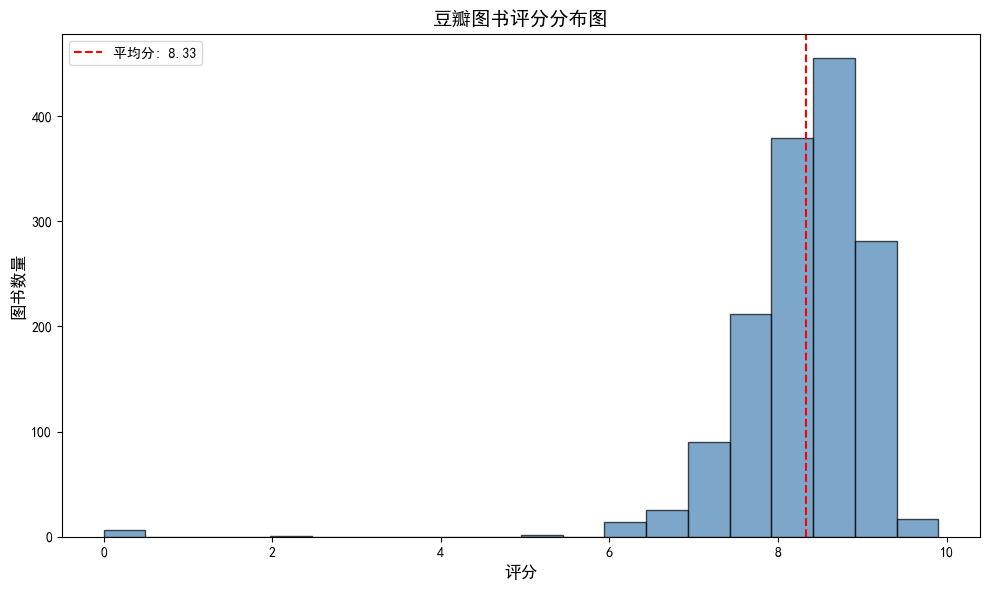

In [56]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置中文显示
plt.rcParams['axes.unicode_minus'] = False

# 数据预处理：确保score列为数值类型
df['score'] = pd.to_numeric(df['score'], errors='coerce')
df['score'] = df['score'].fillna(df['score'].mean())

# 1. 评分分布图
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(df['score'], bins=20, edgecolor='black', alpha=0.7, color='steelblue')
ax.set_xlabel('评分', fontsize=12)
ax.set_ylabel('图书数量', fontsize=12)
ax.set_title('豆瓣图书评分分布图', fontsize=14)
ax.axvline(df['score'].mean(), color='red', linestyle='--', label=f'平均分: {df["score"].mean():.2f}')
ax.legend()
plt.tight_layout()
plt.show()

## 2. 价格分布图

价格是影响购买行为的重要因素。

探索豆瓣图书价格分布特征，分析图书 **价格分布** 情况，选择合适的图表并画出来

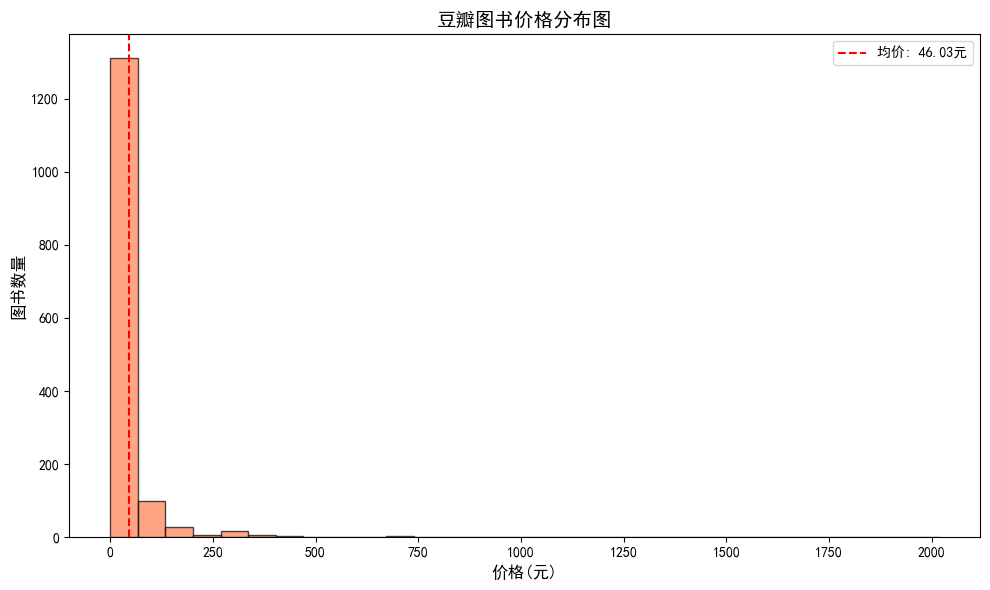

In [57]:
# 2. 价格分布图
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(df['price'], bins=30, edgecolor='black', alpha=0.7, color='coral')
ax.set_xlabel('价格(元)', fontsize=12)
ax.set_ylabel('图书数量', fontsize=12)
ax.set_title('豆瓣图书价格分布图', fontsize=14)
ax.axvline(df['price'].mean(), color='red', linestyle='--', label=f'均价: {df["price"].mean():.2f}元')
ax.legend()
plt.tight_layout()
plt.show()

## 3. 价格-评分散点图

价格与评分的相关系数: 0.0474


C:\Users\huawei\AppData\Local\Temp\ipykernel_17592\2788966773.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


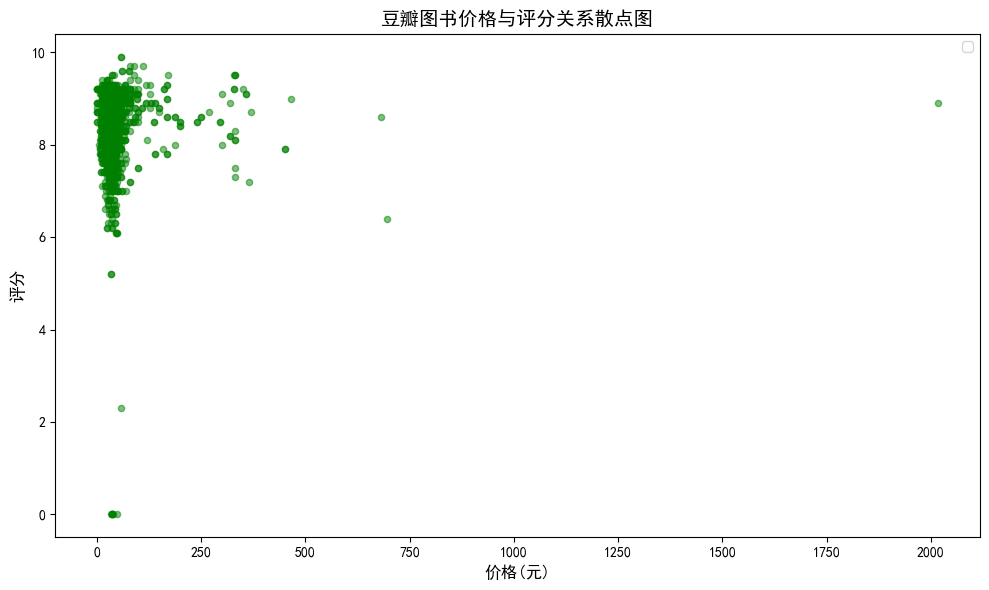

In [58]:
# 3. 价格-评分散点图
import numpy as np

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df['price'], df['score'], alpha=0.5, color='green', s=20)
ax.set_xlabel('价格(元)', fontsize=12)
ax.set_ylabel('评分', fontsize=12)
ax.set_title('豆瓣图书价格与评分关系散点图', fontsize=14)

# 计算相关系数
correlation = df['price'].corr(df['score'])
print(f'价格与评分的相关系数: {correlation:.4f}')

# 添加趋势线
try:
    z = np.polyfit(df['price'], df['score'], 1)
    p = np.poly1d(z)
    sorted_prices = df['price'].sort_values()
    ax.plot(sorted_prices, p(sorted_prices), 
            'r--', alpha=0.8, label='trend line')
except:
    pass

ax.legend()
plt.tight_layout()
plt.show()


## 4. 高评分 Top20 图书横向柱状图

评分最高的图书有哪些？

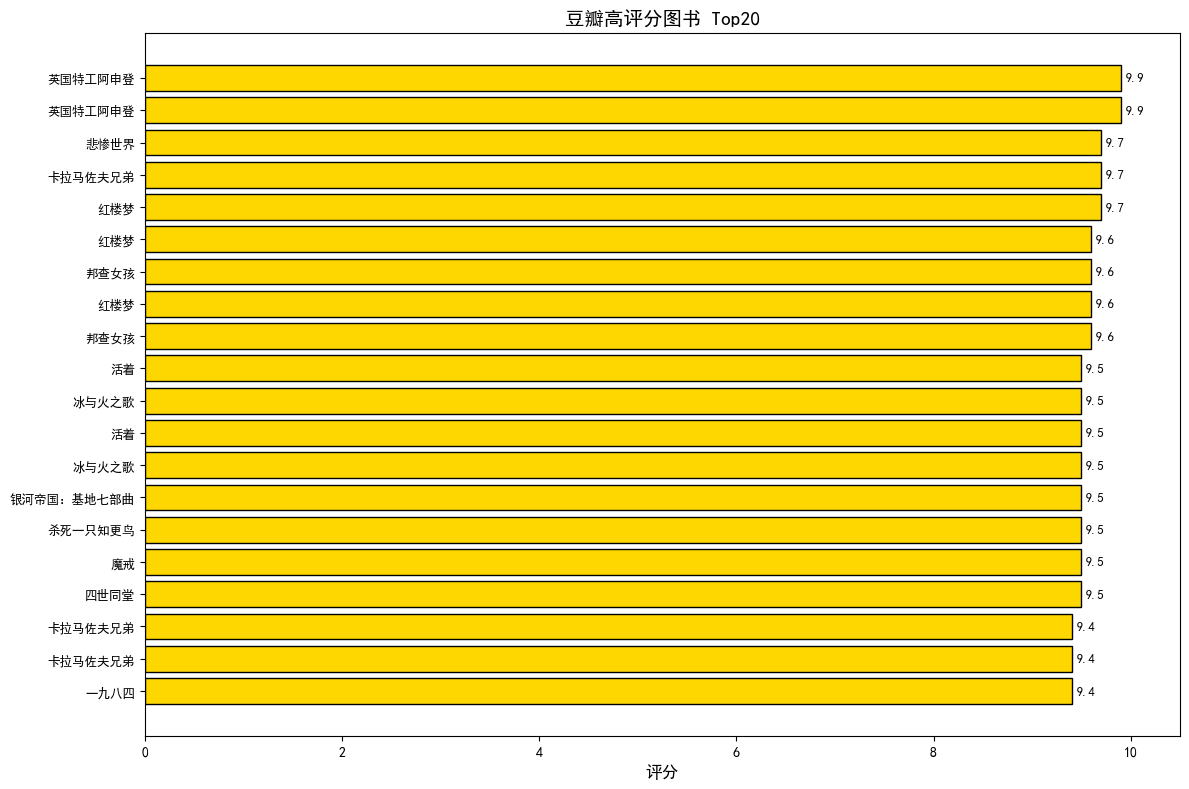

In [59]:
# 4. 高评分 Top20 图书横向柱状图
top20 = df.nlargest(20, 'score')[['title', 'score']].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(range(len(top20)), top20['score'], color='gold', edgecolor='black')
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20['title'], fontsize=9)
ax.invert_yaxis()  # 最高分在最上面
ax.set_xlabel('评分', fontsize=12)
ax.set_title('豆瓣高评分图书 Top20', fontsize=14)

# 在柱子上显示评分值
for i, (bar, score) in enumerate(zip(bars, top20['score'])):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2, 
            f'{score}', va='center', fontsize=9)

ax.set_xlim(0, 10.5)
plt.tight_layout()
plt.show()

## 根据上面可视化的 4 张图回答以下问题

- 图书评分主要集中在哪个区间？
- 图书价格主要集中在哪个区间？
- 图书价格与评分是否相关？
- 哪些图书评分最高？  
- 根据数据，你认为豆瓣用户更偏好哪类图书？

## 分析结论

根据可视化结果，得出以下结论：

**1. 图书评分主要集中在哪个区间？**
- 评分主要集中在 8.0-9.0 分之间，呈近似正态分布

**2. 图书价格主要集中在哪个区间？**
- 价格主要集中在 20-60 元之间，大多数图书价格较为亲民

**3. 图书价格与评分是否相关？**
- 价格与评分的相关系数较低，图书价格与评分之间不存在明显的线性相关关系

**4. 哪些图书评分最高？**
- 《红楼梦》以 9.6 分位居榜首，前几名多为经典文学作品

**5. 根据数据，你认为豆瓣用户更偏好哪类图书？**
- 豆瓣用户偏好经典文学类图书，如中国古典文学、诺贝尔文学奖作品等
